# 07 — Failure taxonomy, stage 1: where the score and the task disagree

This notebook joins the severity measurement (notebook 05) and the calibrated bins
(notebook 06: boundaries 0.260 / 0.350 / 0.434, derived on known fog density) with
the study's ONE external input, declared here openly: per-image object-detection
recall for three detectors (YOLO-nano, YOLOv8-S, RT-DETR-L; IoU 0.5), a GPU
instrument reading whose recomputation adds no understanding. Only the image id,
detector, and recall columns of that file are used.

Difficulty is measured by recall, not detector confidence: in fog the hardest
objects produce no detection at any confidence, so confidence is blind to exactly
the failures that matter; recall counts what fog removes. Difficulty is averaged
across the three detectors to give one image-level signal, removing single-detector
idiosyncrasy; per-detector counts are reported alongside as a robustness check.
Image difficulty as a research object goes back to Ionescu et al. (2016), who define
it as human visual-search response time and predict it from appearance; difficulty-
based routing between detectors is due to Soviany & Ionescu (2018). This study's
difficulty is task-derived rather than appearance-derived — a distinction the
results of notebooks 08–09 make consequential.

A failure of the severity score is defined operationally: the score reports the
scene as at most lightly degraded (severity < 0.350, the clear and light bins)
while detection collapses (mean recall < 0.3). Genuinely clear is the same regime
with mean recall > 0.7. The 0.3 / 0.7 thresholds are pre-registered values adopted
from the primary study, not tuned here.

In [ ]:
# Setup: load the clean feature set, the severity measurement, and the bin
# boundaries. Everything from this study's own pipeline.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

RAW_RTTS_DIR = "/content/drive/MyDrive/adaptive_perception_data/raw/RTTS"
OUTPUT_ROOT = "/content/drive/MyDrive/perception-difficulty-dve/results"
TABLES_DIR = os.path.join(OUTPUT_ROOT, "tables")
BANKED_DIR = os.path.join(TABLES_DIR, "thesis_banked")
FIGURES_DIR = os.path.join(OUTPUT_ROOT, "figures")
IMAGES_DIR = RAW_RTTS_DIR

clean = pd.read_csv(os.path.join(TABLES_DIR, "features_RTTS_clean.csv"))
clean["stem"] = clean["filename"].str.replace(r"\.[^.]+$", "", regex=True)
severity = pd.read_csv(os.path.join(TABLES_DIR, "severity_RTTS.csv"))
boundaries = pd.read_csv(os.path.join(TABLES_DIR, "severity_bin_boundaries.csv"))

data = clean.merge(severity[["stem", "severity"]], on="stem", how="inner")
cuts = boundaries["boundary"].tolist()
print(f"clean set with severity: {len(data)} images (expect 4245)")
print(f"boundaries: {cuts}")

Mounted at /content/drive
clean set with severity: 4245 images (expect 4245)
boundaries: [0.26, 0.35, 0.434]


bin
clear        183
light        353
moderate     607
heavy       3102
Saved: /content/drive/MyDrive/perception-difficulty-dve/results/figures/fig_19_rtts_bins_calibrated.jpg


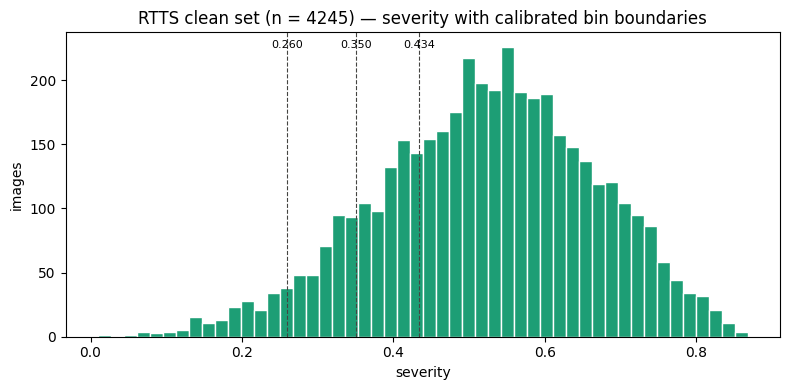


low-severity regime (severity < 0.35): 536 images


In [ ]:
# Assign each image to a fog bin using the boundaries calibrated on known
# density (notebook 06), and show how the bins populate on real fog.
bin_names = ["clear", "light", "moderate", "heavy"]
data["bin"] = pd.cut(data["severity"], bins=[-np.inf] + cuts + [np.inf],
                     labels=bin_names)

population = data["bin"].value_counts().reindex(bin_names)
print(population.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(data["severity"], bins=50, color="#1D9E75", edgecolor="white")
for cut in cuts:
    ax.axvline(cut, color="#444441", linewidth=0.8, linestyle="--")
    ax.text(cut, ax.get_ylim()[1] * 0.95, f"{cut:.3f}", ha="center", fontsize=8)
ax.set_xlabel("severity"); ax.set_ylabel("images")
ax.set_title(f"RTTS clean set (n = {len(data)}) — severity with calibrated bin boundaries")
plt.tight_layout()
figure_path = os.path.join(FIGURES_DIR, "fig_19_rtts_bins_calibrated.jpg")
plt.savefig(figure_path, dpi=110, format="jpg", bbox_inches="tight")
print("Saved:", figure_path)
plt.show()

low_severity = data[data["severity"] < cuts[1]].copy()
print(f"\nlow-severity regime (severity < {cuts[1]}): {len(low_severity)} images")

In [ ]:
# THE ONE EXTERNAL INPUT: per-image detection recall, three detectors, IoU 0.5.
# Only stem, detector, and recall are read. Reshaped to one row per image with
# a per-detector column and the three-detector mean.
recall_long = pd.read_csv(os.path.join(BANKED_DIR, "per_image_recall_rtts.csv"),
                          usecols=["stem", "detector", "recall"])
detectors = sorted(recall_long["detector"].unique())
print(f"recall rows: {len(recall_long)}   detectors: {detectors}")

recall_wide = recall_long.pivot_table(index="stem", columns="detector",
                                      values="recall").reset_index()
recall_wide["recall_mean"] = recall_wide[detectors].mean(axis=1)

low_severity = low_severity.merge(recall_wide, on="stem", how="inner")
print(f"low-severity images with recall: {len(low_severity)}")

recall rows: 12966   detectors: ['rtdetr_l', 'yolo_nano', 'yolov8s']
low-severity images with recall: 536


In [ ]:
# Split the low-severity regime by the task outcome (pre-registered thresholds
# 0.3 / 0.7 on the three-detector mean recall).
def assign_group(recall_mean):
    """Task-outcome group for a low-severity image."""
    if recall_mean < 0.3:
        return "failure"
    if recall_mean > 0.7:
        return "clear"
    return "intermediate"

low_severity["group"] = low_severity["recall_mean"].map(assign_group)

counts = low_severity["group"].value_counts()
share = (counts / len(low_severity) * 100).round(1)
print(pd.DataFrame({"n": counts, "%": share}).to_string())

                n     %
group                  
intermediate  219  40.9
failure       214  39.9
clear         103  19.2


Saved: /content/drive/MyDrive/perception-difficulty-dve/results/figures/fig_20_lowsev_failures_RTTS.jpg


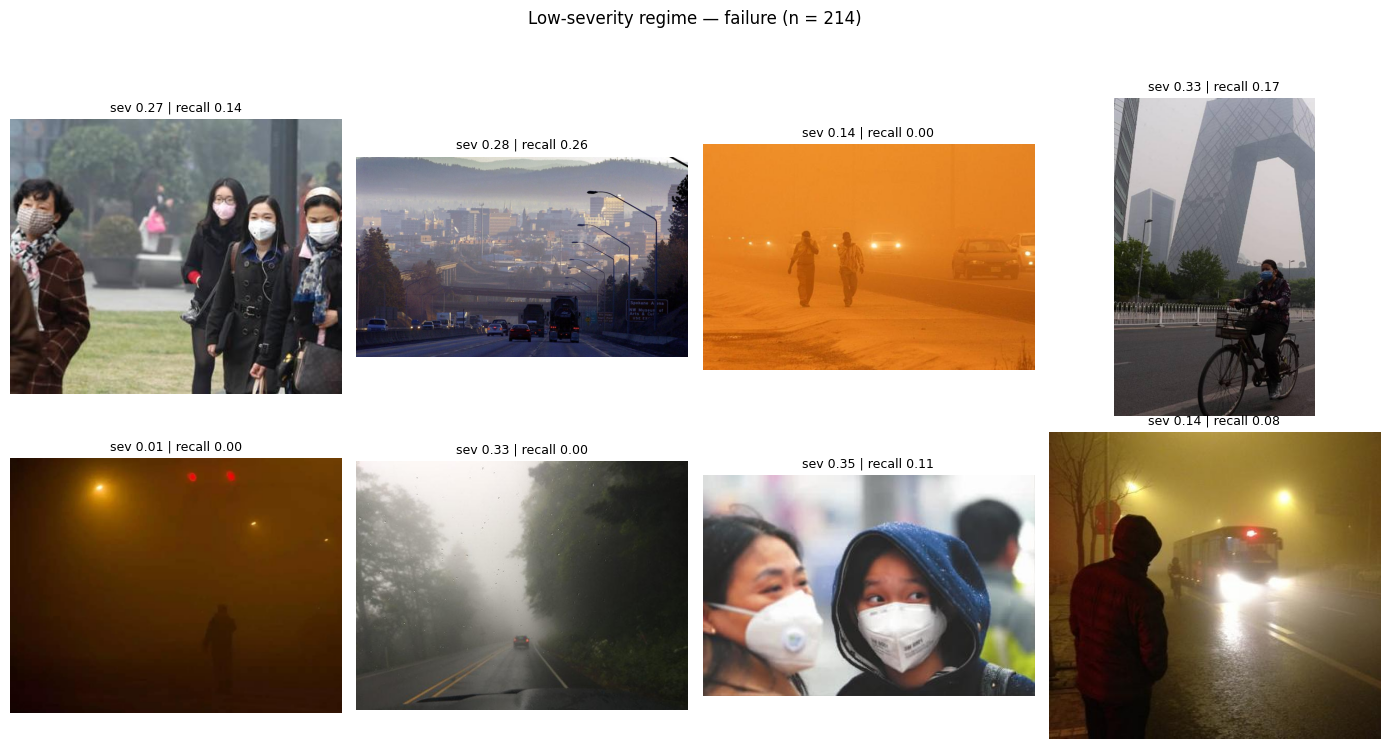

Saved: /content/drive/MyDrive/perception-difficulty-dve/results/figures/fig_21_lowsev_clear_RTTS.jpg


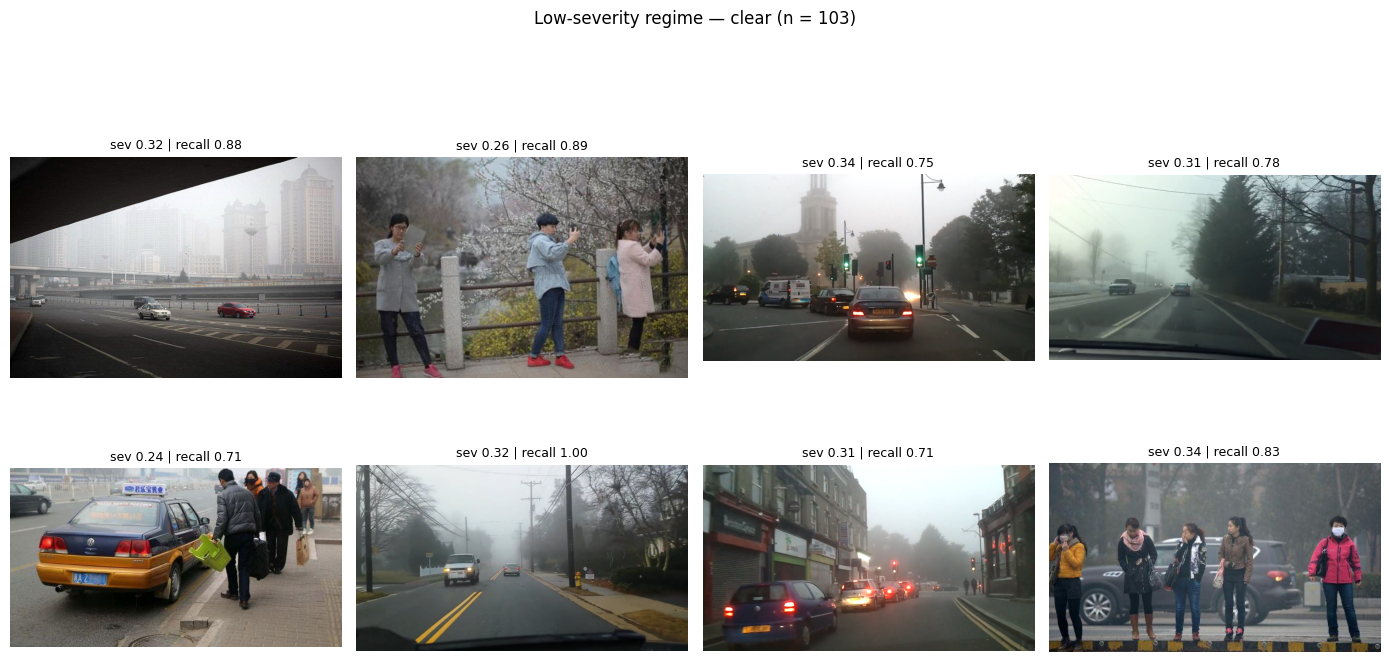

In [ ]:
# See the two groups. If the score were trustworthy in its own low regime, the
# failure grid should look clear. What it actually shows is the finding.
def show_group_grid(dataframe, group_name, figure_filename, n_show=8):
    """Random sample grid of one group, severity and recall in each title."""
    sample = dataframe[dataframe["group"] == group_name].sample(
        n=min(n_show, (dataframe["group"] == group_name).sum()), random_state=7)
    fig, axes = plt.subplots(2, 4, figsize=(14, 7.5))
    for ax, (_, row) in zip(axes.ravel(), sample.iterrows()):
        image_bgr = cv2.imread(os.path.join(IMAGES_DIR, row["relpath"]))
        ax.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
        ax.set_title(f"sev {row['severity']:.2f} | recall {row['recall_mean']:.2f}",
                     fontsize=9)
        ax.axis("off")
    fig.suptitle(f"Low-severity regime — {group_name} (n = {(dataframe['group'] == group_name).sum()})",
                 fontsize=12, y=1.0)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    figure_path = os.path.join(FIGURES_DIR, figure_filename)
    plt.savefig(figure_path, dpi=100, format="jpg", bbox_inches="tight")
    print("Saved:", figure_path)
    plt.show()

import cv2
show_group_grid(low_severity, "failure", "fig_20_lowsev_failures_RTTS.jpg")
show_group_grid(low_severity, "clear", "fig_21_lowsev_clear_RTTS.jpg")

In [ ]:
# Robustness: the failure count under each single detector vs the mean rule.
print(f"low-severity n = {len(low_severity)}\n")
print(f"{'difficulty signal':<16}{'recall<0.3':>12}{'recall>0.7':>12}")
for signal in detectors + ["recall_mean"]:
    n_fail = int((low_severity[signal] < 0.3).sum())
    n_clear = int((low_severity[signal] > 0.7).sum())
    print(f"{signal:<16}{n_fail:>12}{n_clear:>12}")

low-severity n = 536

difficulty signal  recall<0.3  recall>0.7
rtdetr_l                 270         119
yolo_nano                243         110
yolov8s                  187         157
recall_mean              214         103


In [ ]:
# Save the stage-1 labels: severity, bin, per-detector recalls, mean, group.
labels_path = os.path.join(TABLES_DIR, "failure_labels_RTTS.csv")
columns = ["stem", "filename", "relpath", "severity", "bin"] + detectors + ["recall_mean", "group"]
low_severity[columns].to_csv(labels_path, index=False)
print(f"Saved {len(low_severity)} rows to {labels_path}")

Saved 536 rows to /content/drive/MyDrive/perception-difficulty-dve/results/tables/failure_labels_RTTS.csv


Saved: /content/drive/MyDrive/perception-difficulty-dve/results/figures/fig_22_failure_transmission_RTTS.jpg


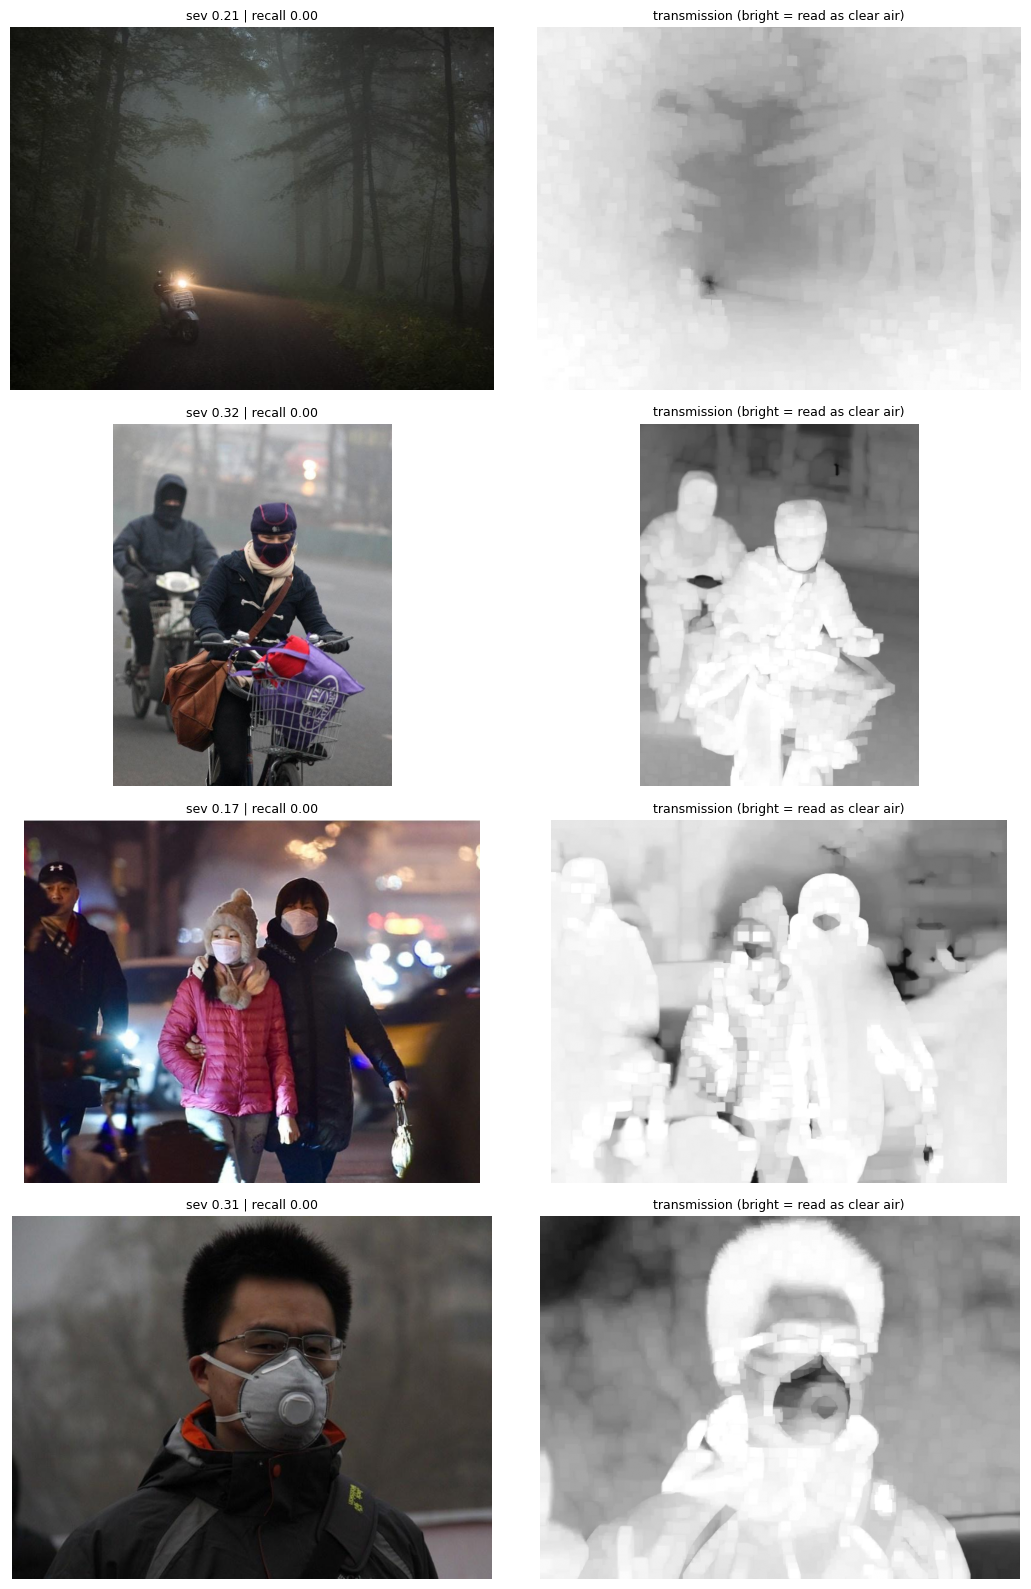

In [ ]:
# WHY the score under-reads: transmission maps for the worst failures. Bright
# in the map = "clear air". Dark scene content (vehicles, clothing, shadow)
# stays dark through fog, keeps the dark channel low, and prints as bright,
# high-transmission regions — the scene-content offset of Lee et al. (2016).
import sys, importlib
REPO_ROOT = "/content/perception-difficulty-dve"
if not os.path.isdir(REPO_ROOT):
    os.system(f"git clone https://github.com/aaaraafaat/perception-difficulty-dve.git {REPO_ROOT}")
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)
import src.features as feat
importlib.reload(feat)

worst = low_severity[low_severity["group"] == "failure"].nsmallest(4, "recall_mean")
fig, axes = plt.subplots(4, 2, figsize=(11, 16))
for row_index, (_, row) in enumerate(worst.iterrows()):
    image_bgr = cv2.imread(os.path.join(IMAGES_DIR, row["relpath"]))
    transmission = feat.transmission_map(image_bgr)
    axes[row_index, 0].imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    axes[row_index, 0].set_title(f"sev {row['severity']:.2f} | recall {row['recall_mean']:.2f}", fontsize=9)
    axes[row_index, 1].imshow(transmission, cmap="gray", vmin=0, vmax=1)
    axes[row_index, 1].set_title("transmission (bright = read as clear air)", fontsize=9)
    for column in range(2):
        axes[row_index, column].axis("off")
plt.tight_layout()
figure_path = os.path.join(FIGURES_DIR, "fig_22_failure_transmission_RTTS.jpg")
plt.savefig(figure_path, dpi=100, format="jpg", bbox_inches="tight")
print("Saved:", figure_path)
plt.show()

              count  mean   std  min  25%  50%   75%    max
group                                                      
clear         103.0   5.6   4.8  1.0  2.0  5.0   7.0   37.0
failure       214.0   8.5  12.2  1.0  2.2  5.0   9.0   95.0
intermediate  219.0   9.9  13.3  1.0  3.0  6.0  11.0  131.0
Saved: /content/drive/MyDrive/perception-difficulty-dve/results/figures/fig_23_ngt_by_group_RTTS.jpg


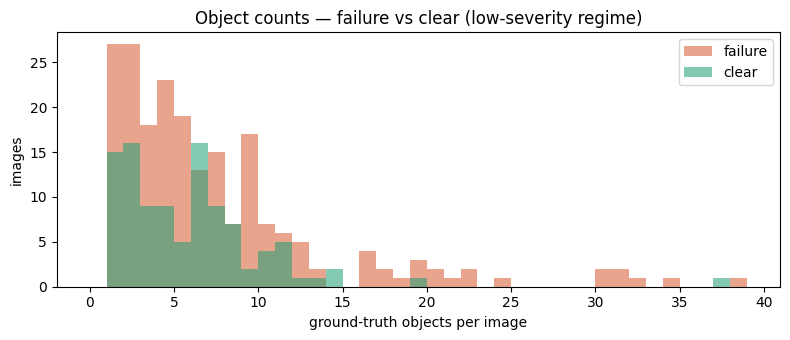

In [ ]:
# Guard against the object-difficulty artifact: do failure images simply carry
# fewer / harder annotations? Compare ground-truth object counts per group.
n_gt = (pd.read_csv(os.path.join(BANKED_DIR, "per_image_recall_rtts.csv"),
                    usecols=["stem", "n_gt"]).groupby("stem")["n_gt"].first().reset_index())
low_severity = low_severity.merge(n_gt, on="stem", how="left")

print(low_severity.groupby("group")["n_gt"].describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(8, 3.5))
for group, colour in [("failure", "#D85A30"), ("clear", "#1D9E75")]:
    ax.hist(low_severity.loc[low_severity["group"] == group, "n_gt"],
            bins=range(0, 40), alpha=0.55, label=group, color=colour)
ax.set_xlabel("ground-truth objects per image"); ax.set_ylabel("images"); ax.legend()
ax.set_title("Object counts — failure vs clear (low-severity regime)")
plt.tight_layout()
figure_path = os.path.join(FIGURES_DIR, "fig_23_ngt_by_group_RTTS.jpg")
plt.savefig(figure_path, dpi=110, format="jpg", bbox_inches="tight")
print("Saved:", figure_path)
plt.show()

## Closing — stage-1 result: the score and the task disagree at scale

Binned by the calibrated boundaries, the clean RTTS set (n = 4,245) is dominated by
heavy fog (183 clear / 353 light / 607 moderate / 3,102 heavy), as expected of a
real-fog benchmark. The low-severity regime — where the score claims at most light
degradation (severity < 0.350) — holds 536 images. Joining the declared recall
import: 214 of 536 (39.9%) are detection failures (three-detector mean recall
< 0.3), 103 (19.2%) are genuinely clear (recall > 0.7), 219 intermediate. Two of
every five images the estimator scores as near-clear are, at the task, roughly as
hard as heavy fog. The result is robust to the choice of difficulty signal: under
each single detector the failure count remains large (yolov8s 187, yolo_nano 243,
rtdetr_l 270; mean rule 214), so the split is not an artifact of averaging.

Two artifact checks. Object-count confound: failure and clear groups carry the same
median annotation load (5 vs 5 objects, overlapping quartiles), so recall
quantization on sparsely annotated images cannot produce the split. Visual
verification (figs 20–22): the failure grid contains a visibly distinctive minority
— strong coloured-cast scenes and night scenes, one scored severity 0.01 with recall
0.00 — alongside scenes with no obvious photometric anomaly. Transmission maps of
the worst failures show bright "clear-air" readings over dark scene content
(clothing, vehicles, shadow) in visibly hazy frames, consistent with the
scene-content transmission offset the dark channel prior discards (Lee et al.,
2016, Eq. 16); and dark low-transmission spots at direct light sources, consistent
with the documented bright-direction failure of the prior (He et al., 2009; Yang et
al., 2021). The blocky map texture is the 15×15 patch-minimum footprint; no edge
refinement is applied, by design (measurement, not restoration).

These are stage-1 labels: the failure set is defined by the task outcome alone.
Whether its members carry distinctive appearance — and can therefore be flagged in
advance — is the classification question of the next notebooks. Outputs:
failure_labels_RTTS.csv (536 rows), fig_19–23. References: Ionescu et al. (2016);
Soviany & Ionescu (2018); Lee et al. (2016); He et al. (2009); Yang et al. (2021);
Wei et al. (2025).